# 03 Portfolio Assembly (FINAL)

This notebook backtests **only your final signal** `sig_igl_global_elite_combo` (plus a Buy & Hold benchmark) using the split:

- **Train:** 2000-01-01 → 2015-12-31  
- **Test:**  2016-01-01 → 2021-12-31  

Designed to be robust to:
- running from any folder (auto-finds your project root by locating `src/`)
- Barchart CSV header/footer text rows (drops non-date rows)
- different column naming conventions (maps to both `signals.py` and `backtest_engine.py` expectations)

In [ ]:
# -----------------------------
# 1) Imports + Project Root Finder
# -----------------------------
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start=None, max_up: int = 8) -> Path:
    """Find a project root by searching upwards for a folder that contains 'src/'."""
    cur = (start or Path.cwd()).resolve()
    for _ in range(max_up + 1):
        if (cur / "src").exists() and (cur / "src").is_dir():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        "Could not find project root containing a 'src/' folder. "
        "Run this notebook inside your repo, or set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = (PROJECT_ROOT / "src").resolve()

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("SRC_DIR       =", SRC_DIR)


signals_mod = importlib.import_module("signals")           # src/signals.py
bt_mod      = importlib.import_module("backtest_engine")   # src/backtest_engine.py
utils_mod   = importlib.import_module("utils")             # src/utils.py

print("Loaded:", signals_mod.__file__)
print("Loaded:", bt_mod.__file__)
print("Loaded:", utils_mod.__file__)

PROJECT_ROOT = C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project
SRC_DIR       = C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src
Loaded: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py
Loaded: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\backtest_engine.py
Loaded: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\utils.py


In [2]:
# -----------------------------
# 2) Load & Standardize Data
# -----------------------------
def load_qqq_csv(path: Path) -> pd.DataFrame:
    """Load QQQ CSV and return a DataFrame indexed by Date with lowercase OHLCV."""
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    # Date parsing (robust to Barchart metadata lines)
    if "Time" in df.columns:
        dt = pd.to_datetime(df["Time"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    else:
        raise ValueError("Could not find a 'Time' or 'Date' column in the CSV.")

    df["Date"] = dt
    df = df.dropna(subset=["Date"]).copy()
    df = df.sort_values("Date").set_index("Date")

    # Map common vendor column names to lowercase
    rename_map = {}
    if "Latest" in df.columns and "close" not in df.columns:
        rename_map["Latest"] = "close"
    if "Open" in df.columns and "open" not in df.columns:
        rename_map["Open"] = "open"
    if "High" in df.columns and "high" not in df.columns:
        rename_map["High"] = "high"
    if "Low" in df.columns and "low" not in df.columns:
        rename_map["Low"] = "low"
    if "Volume" in df.columns and "volume" not in df.columns:
        rename_map["Volume"] = "volume"
    if "Change" in df.columns and "change" not in df.columns:
        rename_map["Change"] = "change"

    df = df.rename(columns=rename_map)

    # Force numeric where possible
    for c in ["open", "high", "low", "close", "volume"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["close"]).copy()
    return df

# Default paths (edit if needed)
DATA_PATH_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "qqq_train_validation.csv",
    PROJECT_ROOT / "qqq_train_validation.csv",
    PROJECT_ROOT / "data" / "raw" / "input_file_0.csv",
]

DATA_PATH = None
for p in DATA_PATH_CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find a data file automatically. "
        "Set DATA_PATH to your CSV path explicitly."
    )

print("Using data file:", DATA_PATH)
df = load_qqq_csv(DATA_PATH)

print("Date range:", df.index.min(), "→", df.index.max())
print("Columns:", list(df.columns))
df.head()

Using data file: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\data\raw\qqq_train_validation.csv
Date range: 2000-01-03 00:00:00 → 2021-12-31 00:00:00
Columns: ['Time', 'open', 'high', 'low', 'close', 'change', '%Change', 'volume']


C:\Users\brijp\AppData\Local\Temp\ipykernel_25160\4048719046.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt = pd.to_datetime(df["Time"], errors="coerce")


,Time,open,high,low,close,change,%Change,volume
Date,,,,,,,,
2000-01-03,1/3/00,81.3772,81.3772,76.7749,80.1589,2.8552,3.69%,85922031
2000-01-04,1/4/00,77.8324,79.1014,74.3976,74.6599,-5.4990,-6.86%,79873331
2000-01-05,1/5/00,74.0254,75.8232,71.2759,72.7564,-1.9035,-2.55%,100464224
2000-01-06,1/6/00,73.4966,74.4484,67.4689,67.7607,-4.9957,-6.87%,87788706
2000-01-07,1/7/00,70.1676,76.1404,69.7954,76.1404,8.3797,12.37%,66520215


In [3]:
from pathlib import Path
import importlib.util
import sys

SIGNALS_PATH = Path(r"C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py")

def import_module_from_path(module_name: str, path: Path):
    path = Path(path)
    assert path.exists(), f"File not found: {path}"

    # Ensure src/ is on sys.path so "import utils" inside signals.py works
    src_dir = str(path.parent)
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    spec = importlib.util.spec_from_file_location(module_name, str(path))
    mod = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(mod)  # type: ignore
    return mod

signals_mod = import_module_from_path("signals_mod", SIGNALS_PATH)

print("Loaded signals from:", signals_mod.__file__)
print("Has sig_igl_global_elite_combo?", hasattr(signals_mod, "sig_igl_2plus_combo"))


Loaded signals from: C:\Users\brijp\OneDrive\Desktop\PersonalProjects\Quanta_Fellowship_Project\src\signals.py
Has sig_igl_global_elite_combo? True


In [ ]:
# -----------------------------
# 3) Build the final signal (IGL Global Elite)
# -----------------------------


df_sig = df.copy()

lev_igl = signals_mod.sig_igl_2plus_combo(df_sig)


In [5]:
# -----------------------------
# 4) Backtest (ONLY final signal + Buy&Hold) using backtest_engine.py
# -----------------------------
TRAIN_START, TRAIN_END = "2000-01-01", "2015-12-31"
TEST_START,  TEST_END  = "2016-01-01", "2021-12-31"

lev_bh = pd.Series(1.0, index=df.index)

bt_igl, stats_igl = bt_mod.backtest_leverage_signal(df, lev_igl, name="igl_2plus_combo")
bt_bh,  stats_bh  = bt_mod.backtest_leverage_signal(df, lev_bh,  name="BuyHold")

print("Backtest days (IGL):", stats_igl.get("n_days"))
print("Backtest days (BH) :", stats_bh.get("n_days"))

Backtest days (IGL): 5535
Backtest days (BH) : 5535


In [6]:
# -----------------------------
# 5) Train/Test metrics table
# -----------------------------
def slice_stats(bt_df: pd.DataFrame, start: str, end: str) -> dict:
    s = bt_df.loc[start:end].copy()
    if len(s) == 0:
        return {"sharpe": 0.0, "calmar": np.nan, "total_ret": 0.0, "max_dd": 0.0, "n": 0}
    r = s["ret"].dropna()
    if len(r) == 0:
        return {"sharpe": 0.0, "calmar": np.nan, "total_ret": 0.0, "max_dd": 0.0, "n": 0}
    sharpe = utils_mod.annualized_sharpe(r)
    calmar = utils_mod.calmar_ratio(r)
    equity = (1.0 + r).cumprod()
    total_ret = float(equity.iloc[-1] - 1.0)
    max_dd = float(utils_mod.max_drawdown(equity))
    return {"sharpe": float(sharpe), "calmar": float(calmar), "total_ret": total_ret, "max_dd": max_dd, "n": int(len(r))}

rows = []
for name, bt_df, stats_full in [
    ("IGL_Global_Elite", bt_igl, stats_igl),
    ("BuyHold", bt_bh, stats_bh),
]:
    tr = slice_stats(bt_df, TRAIN_START, TRAIN_END)
    te = slice_stats(bt_df, TEST_START, TEST_END)
    rows.append({
        "Strategy": name,
        "Train Sharpe": tr["sharpe"],
        "Train Calmar": tr["calmar"],
        "Train Ret": tr["total_ret"],
        "Train MaxDD": tr["max_dd"],
        "Test Sharpe": te["sharpe"],
        "Test Calmar": te["calmar"],
        "Test Ret": te["total_ret"],
        "Test MaxDD": te["max_dd"],
        "Avg Turnover": float(stats_full.get("avg_turnover", np.nan)),
        "n_days_full": int(stats_full.get("n_days", 0)),
    })

results = pd.DataFrame(rows).set_index("Strategy")
results

,Train Sharpe,Train Calmar,Train Ret,Train MaxDD,Test Sharpe,Test Calmar,Test Ret,Test MaxDD,Avg Turnover,n_days_full
Strategy,,,,,,,,,,
IGL_Global_Elite,0.387622,0.116185,0.966450,-0.372223,1.569577,1.890619,2.404011,-0.119974,0.050551,5535
BuyHold,0.197330,0.018193,0.270333,-0.829639,1.150280,0.876663,2.814695,-0.285594,0.000000,5535


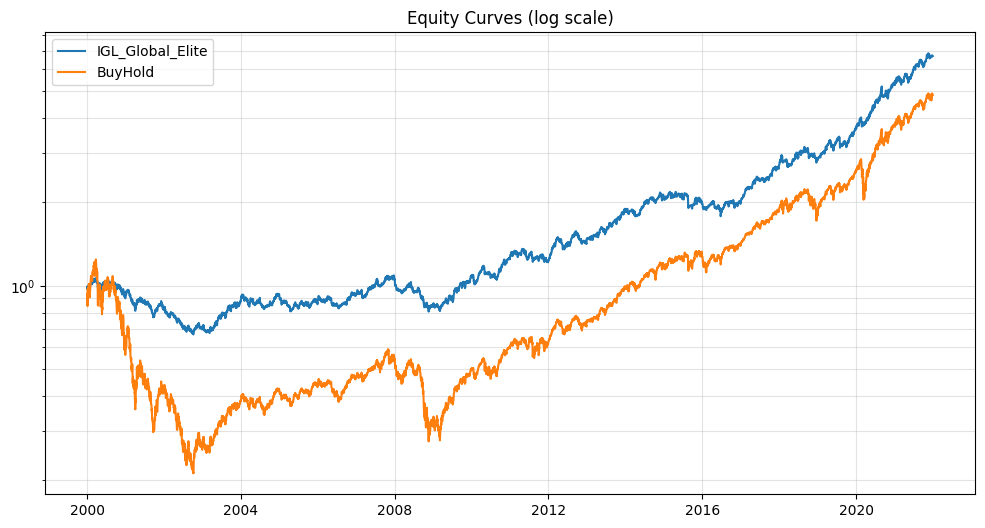

In [7]:
# -----------------------------
# 6) Plot equity curves (log scale)
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(bt_igl["equity"], label="IGL_Global_Elite")
plt.plot(bt_bh["equity"], label="BuyHold")
plt.yscale("log")
plt.title("Equity Curves (log scale)")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.show()